In [1]:
from google.colab import drive
# Load the data set and unzip it.
drive.mount('/content/drive')
import zipfile
zip_path = '/content/drive/MyDrive/Snake_FeaturedDataset.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Dataset extracted successfully!")

Mounted at /content/drive
Dataset extracted successfully!


In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import RobustScaler, QuantileTransformer, PowerTransformer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

In [3]:
# UNSUPERVISED CLUSTERING

# Step 1: Setup and Data Loading
features_path = "/content"

try:
    X = np.load(os.path.join(features_path, "selected_features.npy"))
    y_true = np.load(os.path.join(features_path, "labels.npy"))
    print(f" Loaded: selected_features.npy ({X.shape})")
    print(f" Loaded: labels.npy ({y_true.shape}) - FOR EVALUATION ONLY")
except FileNotFoundError as e:
    print(f" Error loading files: {e}")
    feature_files = [f for f in os.listdir(features_path) if f.endswith('.npy')]
    print(f"Available files: {feature_files}")
    if feature_files:
        X = np.load(os.path.join(features_path, feature_files[0]))
        y_true = np.load(os.path.join(features_path, "labels.npy"))

print(f"● Data: {X.shape[0]:,} samples, {X.shape[1]} features")

# Memory optimization
if X.shape[0] > 15000:
    print(f" Large dataset detected, using 10,000 sample subset for faster tuning")
    indices = np.random.choice(X.shape[0], 10000, replace=False)
    X = X[indices]
    y_true = y_true[indices]
    print(f"● Subset: {X.shape[0]:,} samples")

 Loaded: selected_features.npy ((33117, 500))
 Loaded: labels.npy ((33117,)) - FOR EVALUATION ONLY
● Data: 33,117 samples, 500 features
 Large dataset detected, using 10,000 sample subset for faster tuning
● Subset: 10,000 samples


In [5]:
# Step 2: THREE DIFFERENT PRE-PROCESSING METHODS

preprocessing_methods = {
    'RobustScaler': RobustScaler(),
    'PowerTransformer': PowerTransformer(method='yeo-johnson'),
    'QuantileTransformer_Normal': QuantileTransformer(output_distribution='normal', random_state=42)
}

preprocessing_results = {}

for preproc_name, preprocessor in preprocessing_methods.items():
    print(f" Applying: {preproc_name}")
    X_processed = preprocessor.fit_transform(X)
    preprocessing_results[preproc_name] = {
        'data': X_processed,
        'preprocessor': preprocessor
    }
    print(f"    Completed")

 Applying: RobustScaler
    Completed
 Applying: PowerTransformer
    Completed
 Applying: QuantileTransformer_Normal
    Completed


   Tuning for RobustScaler...
    Best params: {'init': 'k-means++', 'n_clusters': 2, 'n_init': 5}
    Best silhouette: nan
   Tuning for PowerTransformer...
    Best params: {'init': 'k-means++', 'n_clusters': 2, 'n_init': 5}
    Best silhouette: nan
   Tuning for QuantileTransformer_Normal...
    Best params: {'init': 'k-means++', 'n_clusters': 2, 'n_init': 5}
    Best silhouette: nan

2.  MANUAL TUNING - Elbow Method Analysis...
   Elbow analysis for RobustScaler...
    Optimal k from silhouette: 2
   Elbow analysis for PowerTransformer...
    Optimal k from silhouette: 2
   Elbow analysis for QuantileTransformer_Normal...
    Optimal k from silhouette: 2

 VISUALIZING PARAMETER TUNING RESULTS...


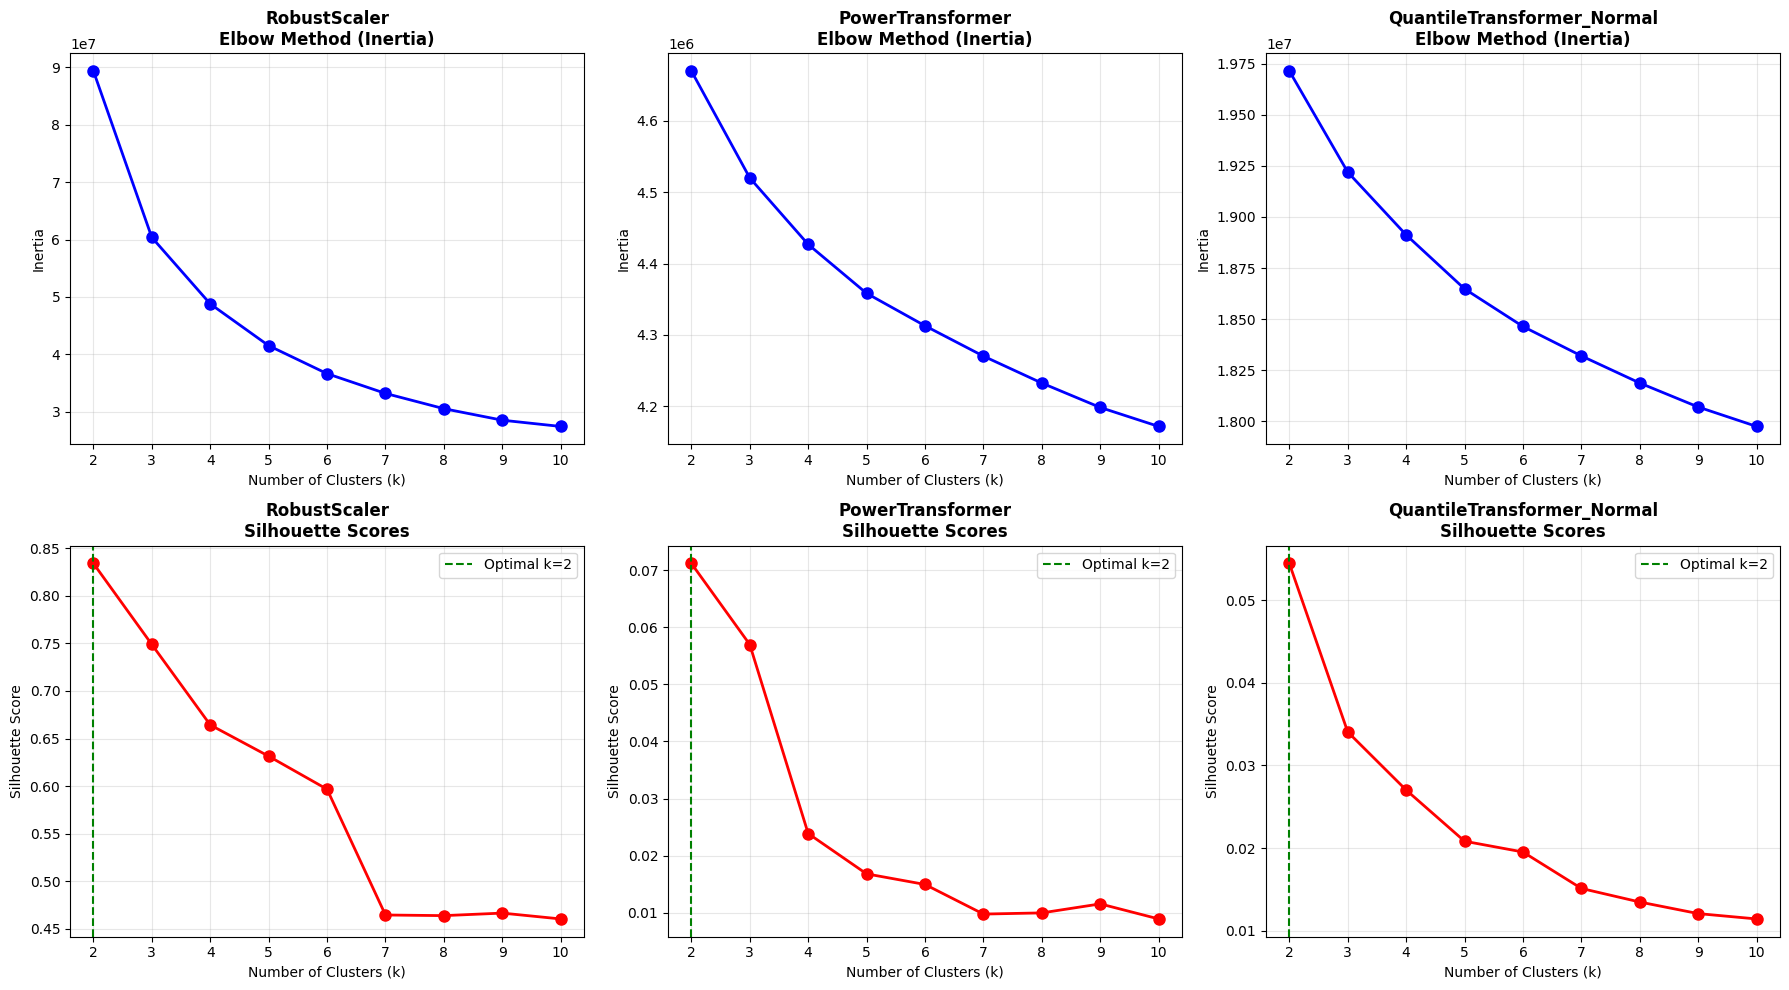

In [6]:
# Step 3: PARAMETER TUNING METHODS - GRIDSEARCHCV & MANUAL TUNING

# Method 1: GridSearchCV for optimal cluster count

def find_optimal_clusters_gridsearch(X, max_clusters=10):
    """Use GridSearchCV to find optimal number of clusters"""
    param_grid = {
        'n_clusters': range(2, max_clusters + 1),
        'init': ['k-means++', 'random'],
        'n_init': [5, 10, 15]
    }

    # Custom scorer for unsupervised clustering (silhouette score)
    from sklearn.metrics import make_scorer
    silhouette_scorer = make_scorer(silhouette_score, metric='euclidean')

    grid_search = GridSearchCV(
        KMeans(random_state=42),
        param_grid,
        scoring=silhouette_scorer,
        cv=3,
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X)

    return grid_search.best_params_, grid_search.best_score_

# Apply GridSearchCV to find optimal parameters
optimal_params = {}
for preproc_name, preproc_result in preprocessing_results.items():
    print(f"   Tuning for {preproc_name}...")
    X_processed = preproc_result['data']

    best_params, best_score = find_optimal_clusters_gridsearch(X_processed, max_clusters=8)
    optimal_params[preproc_name] = {
        'best_params': best_params,
        'best_score': best_score
    }

    print(f"    Best params: {best_params}")
    print(f"    Best silhouette: {best_score:.4f}")

# Method 2: Manual Tuning - Elbow Method for cluster validation
print("\n2.  MANUAL TUNING - Elbow Method Analysis...")

def elbow_method_analysis(X, max_k=10):
    """Manual tuning using elbow method"""
    inertias = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)

        if len(np.unique(labels)) > 1:
            sil_score = silhouette_score(X, labels)
            silhouette_scores.append(sil_score)
        else:
            silhouette_scores.append(0)

    return k_range, inertias, silhouette_scores

# Apply elbow method to each pre-processing
elbow_results = {}
for preproc_name, preproc_result in preprocessing_results.items():
    print(f"   Elbow analysis for {preproc_name}...")
    X_processed = preproc_result['data']

    k_range, inertias, sil_scores = elbow_method_analysis(X_processed)
    elbow_results[preproc_name] = {
        'k_range': k_range,
        'inertias': inertias,
        'silhouette_scores': sil_scores
    }

    # Find optimal k from elbow (manual inspection)
    optimal_k = k_range[np.argmax(sil_scores)]
    print(f"    Optimal k from silhouette: {optimal_k}")

# Visualize elbow method results
print(f"\n VISUALIZING PARAMETER TUNING RESULTS...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (preproc_name, result) in enumerate(elbow_results.items()):
    # Elbow curve (inertia)
    axes[0, idx].plot(result['k_range'], result['inertias'], 'bo-', linewidth=2, markersize=8)
    axes[0, idx].set_title(f'{preproc_name}\nElbow Method (Inertia)', fontweight='bold')
    axes[0, idx].set_xlabel('Number of Clusters (k)')
    axes[0, idx].set_ylabel('Inertia')
    axes[0, idx].grid(True, alpha=0.3)

    # Silhouette scores
    axes[1, idx].plot(result['k_range'], result['silhouette_scores'], 'ro-', linewidth=2, markersize=8)
    axes[1, idx].set_title(f'{preproc_name}\nSilhouette Scores', fontweight='bold')
    axes[1, idx].set_xlabel('Number of Clusters (k)')
    axes[1, idx].set_ylabel('Silhouette Score')
    axes[1, idx].grid(True, alpha=0.3)

    # Mark optimal k
    optimal_k = result['k_range'][np.argmax(result['silhouette_scores'])]
    axes[1, idx].axvline(x=optimal_k, color='green', linestyle='--',
                        label=f'Optimal k={optimal_k}')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

In [7]:
# Step 4: K-MEANS WITH 3 TUNED VARIETIES

# Create varieties based on tuning results
kmeans_varieties = {
    'KMeans_GridSearch_Tuned': {
        'description': 'GridSearchCV optimized parameters',
        'tuning_method': 'GridSearchCV',
        'get_model': lambda preproc_name: KMeans(
            **optimal_params[preproc_name]['best_params'],
            random_state=42
        )
    },
    'KMeans_Elbow_Optimal': {
        'description': 'Elbow method optimal k',
        'tuning_method': 'Manual Tuning (Elbow)',
        'get_model': lambda preproc_name: KMeans(
            n_clusters=elbow_results[preproc_name]['k_range'][
                np.argmax(elbow_results[preproc_name]['silhouette_scores'])
            ],
            init='k-means++',
            n_init=10,
            random_state=42
        )
    },
    'KMeans_Manual_Fixed': {
        'description': 'Manual fixed parameters (baseline)',
        'tuning_method': 'Manual Fixed',
        'get_model': lambda preproc_name: KMeans(
            n_clusters=2,  # Fixed based on binary classification
            init='k-means++',
            n_init=10,
            random_state=42
        )
    }
}

print(" K-Means Varieties with Parameter Tuning:")
for variety_name, config in kmeans_varieties.items():
    print(f"   • {variety_name}: {config['description']}")
    print(f"     Tuning Method: {config['tuning_method']}")


 K-Means Varieties with Parameter Tuning:
   • KMeans_GridSearch_Tuned: GridSearchCV optimized parameters
     Tuning Method: GridSearchCV
   • KMeans_Elbow_Optimal: Elbow method optimal k
     Tuning Method: Manual Tuning (Elbow)
   • KMeans_Manual_Fixed: Manual fixed parameters (baseline)
     Tuning Method: Manual Fixed


In [8]:
# Step 5: COMPREHENSIVE EVALUATION WITH TUNED MODELS

clustering_results = []
total_combinations = len(preprocessing_results) * len(kmeans_varieties)
current_combination = 0

for preproc_name, preproc_result in preprocessing_results.items():
    X_processed = preproc_result['data']

    for variety_name, variety_config in kmeans_varieties.items():
        current_combination += 1
        print(f"\n [{current_combination}/{total_combinations}] {variety_name} + {preproc_name}")
        print(f"   Tuning Method: {variety_config['tuning_method']}")

        start_time = time.time()

        try:
            # Get tuned model for this combination
            kmeans_model = variety_config['get_model'](preproc_name)

            # Display tuned parameters
            if hasattr(kmeans_model, 'n_clusters'):
                print(f"   Tuned Parameters: n_clusters={kmeans_model.n_clusters}, "
                      f"init='{kmeans_model.init}', n_init={kmeans_model.n_init}")

            # FIT CLUSTERING with tuned parameters
            cluster_labels = kmeans_model.fit_predict(X_processed)
            fit_time = time.time() - start_time

            # Calculate metrics
            unique_clusters = len(np.unique(cluster_labels))

            if unique_clusters > 1:
                sil_score = silhouette_score(X_processed, cluster_labels)
                ch_score = calinski_harabasz_score(X_processed, cluster_labels)
                db_score = davies_bouldin_score(X_processed, cluster_labels)
            else:
                sil_score = ch_score = db_score = -1

            result = {
                'preprocessing': preproc_name,
                'model_variety': variety_name,
                'tuning_method': variety_config['tuning_method'],
                'description': variety_config['description'],
                'n_clusters': kmeans_model.n_clusters,
                'clusters_found': unique_clusters,
                'silhouette': sil_score,
                'calinski_harabasz': ch_score,
                'davies_bouldin': db_score,
                'inertia': kmeans_model.inertia_,
                'time': fit_time,
                'model_object': kmeans_model,
                'labels': cluster_labels
            }

            clustering_results.append(result)

            print(f"    Clusters: {unique_clusters}, Silhouette: {sil_score:.3f}")
            print(f"     Completed in {fit_time:.2f}s")

        except Exception as e:
            error_time = time.time() - start_time
            print(f"    Failed: {str(e)[:100]}...")

print(f"\n COMPLETED ALL {total_combinations} TUNED COMBINATIONS!")


 [1/9] KMeans_GridSearch_Tuned + RobustScaler
   Tuning Method: GridSearchCV
   Tuned Parameters: n_clusters=2, init='k-means++', n_init=5
    Clusters: 2, Silhouette: 0.834
     Completed in 1.09s

 [2/9] KMeans_Elbow_Optimal + RobustScaler
   Tuning Method: Manual Tuning (Elbow)
   Tuned Parameters: n_clusters=2, init='k-means++', n_init=10
    Clusters: 2, Silhouette: 0.834
     Completed in 1.27s

 [3/9] KMeans_Manual_Fixed + RobustScaler
   Tuning Method: Manual Fixed
   Tuned Parameters: n_clusters=2, init='k-means++', n_init=10
    Clusters: 2, Silhouette: 0.834
     Completed in 1.23s

 [4/9] KMeans_GridSearch_Tuned + PowerTransformer
   Tuning Method: GridSearchCV
   Tuned Parameters: n_clusters=2, init='k-means++', n_init=5
    Clusters: 2, Silhouette: 0.071
     Completed in 1.46s

 [5/9] KMeans_Elbow_Optimal + PowerTransformer
   Tuning Method: Manual Tuning (Elbow)
   Tuned Parameters: n_clusters=2, init='k-means++', n_init=10
    Clusters: 2, Silhouette: 0.071
     Compl

In [9]:
# Step 6: TUNING EFFECTIVENESS ANALYSIS

# Convert to DataFrame
clustering_df = pd.DataFrame(clustering_results)

# Compare tuning methods
print(f"\n TUNING METHOD PERFORMANCE COMPARISON:")
tuning_performance = clustering_df.groupby('tuning_method').agg({
    'silhouette': ['mean', 'max', 'min', 'std'],
    'time': 'mean',
    'n_clusters': 'mean'
}).round(4)
print(tuning_performance)

# Best parameters found by each method
print(f"\n BEST PARAMETERS FOUND BY EACH TUNING METHOD:")
for preproc_name in preprocessing_results.keys():
    print(f"\n   For {preproc_name}:")
    if preproc_name in optimal_params:
        grid_params = optimal_params[preproc_name]['best_params']
        print(f"   • GridSearchCV: {grid_params}")

    if preproc_name in elbow_results:
        optimal_k = elbow_results[preproc_name]['k_range'][
            np.argmax(elbow_results[preproc_name]['silhouette_scores'])
        ]
        print(f"   • Elbow Method: n_clusters={optimal_k}")

    print(f"   • Manual Fixed: n_clusters=2")

# Display all tuned models
print(f"\n ALL TUNED MODELS RANKED BY PERFORMANCE:")
valid_results = clustering_df[clustering_df['silhouette'] > 0]
if not valid_results.empty:
    ranked_models = valid_results.nlargest(10, 'silhouette')[
        ['tuning_method', 'preprocessing', 'n_clusters', 'silhouette', 'calinski_harabasz', 'time']
    ]
    print(ranked_models.round(4).to_string(index=False))


 TUNING METHOD PERFORMANCE COMPARISON:
                      silhouette                            time n_clusters
                            mean     max     min     std    mean       mean
tuning_method                                                              
GridSearchCV              0.3199  0.8341  0.0544  0.4454  1.2839        2.0
Manual Fixed              0.3199  0.8341  0.0544  0.4454  1.4453        2.0
Manual Tuning (Elbow)     0.3199  0.8341  0.0544  0.4454  1.5010        2.0

 BEST PARAMETERS FOUND BY EACH TUNING METHOD:

   For RobustScaler:
   • GridSearchCV: {'init': 'k-means++', 'n_clusters': 2, 'n_init': 5}
   • Elbow Method: n_clusters=2
   • Manual Fixed: n_clusters=2

   For PowerTransformer:
   • GridSearchCV: {'init': 'k-means++', 'n_clusters': 2, 'n_init': 5}
   • Elbow Method: n_clusters=2
   • Manual Fixed: n_clusters=2

   For QuantileTransformer_Normal:
   • GridSearchCV: {'init': 'k-means++', 'n_clusters': 2, 'n_init': 5}
   • Elbow Method: n_clusters=2


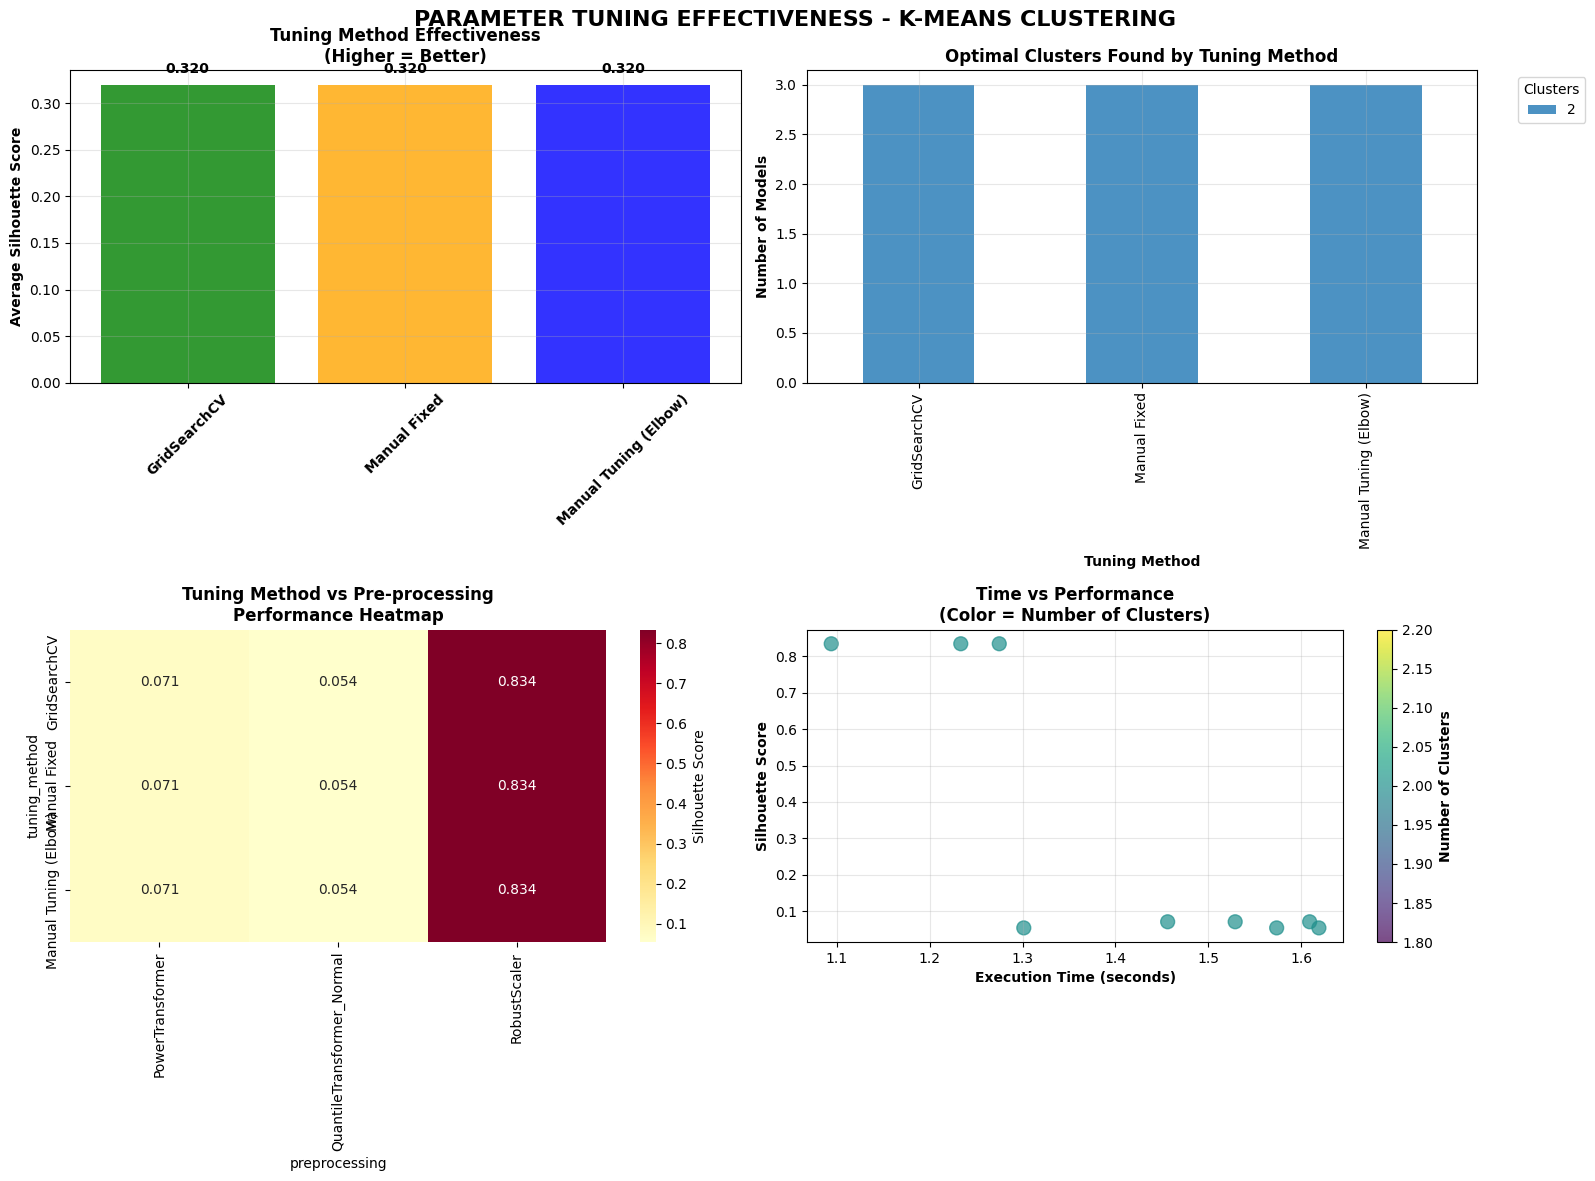

In [10]:
# Step 7: ADVANCED VISUALIZATIONS - TUNING IMPACT

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PARAMETER TUNING EFFECTIVENESS - K-MEANS CLUSTERING',
             fontsize=16, fontweight='bold')

# 1. Tuning Method Comparison
tuning_silhouette = clustering_df.groupby('tuning_method')['silhouette'].mean().sort_values(ascending=False)
bars1 = axes[0,0].bar(range(len(tuning_silhouette)), tuning_silhouette.values,
                     color=['green', 'orange', 'blue'], alpha=0.8)
axes[0,0].set_xticks(range(len(tuning_silhouette)))
axes[0,0].set_xticklabels(tuning_silhouette.index, rotation=45, fontweight='bold')
axes[0,0].set_ylabel('Average Silhouette Score', fontweight='bold')
axes[0,0].set_title('Tuning Method Effectiveness\n(Higher = Better)', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

for i, v in enumerate(tuning_silhouette.values):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Optimal Cluster Distribution
optimal_clusters = clustering_df.groupby(['tuning_method', 'n_clusters']).size().unstack(fill_value=0)
optimal_clusters.plot(kind='bar', ax=axes[0,1], alpha=0.8)
axes[0,1].set_title('Optimal Clusters Found by Tuning Method', fontweight='bold')
axes[0,1].set_xlabel('Tuning Method', fontweight='bold')
axes[0,1].set_ylabel('Number of Models', fontweight='bold')
axes[0,1].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,1].grid(True, alpha=0.3)

# 3. Tuning Method vs Pre-processing Heatmap
pivot_tuning = clustering_df.pivot_table(
    index='tuning_method',
    columns='preprocessing',
    values='silhouette',
    aggfunc='mean'
)
sns.heatmap(pivot_tuning, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1,0],
            cbar_kws={'label': 'Silhouette Score'})
axes[1,0].set_title('Tuning Method vs Pre-processing\nPerformance Heatmap', fontweight='bold')

# 4. Execution Time vs Performance
scatter = axes[1,1].scatter(clustering_df['time'], clustering_df['silhouette'],
                           c=clustering_df['n_clusters'], cmap='viridis',
                           s=100, alpha=0.7)
axes[1,1].set_xlabel('Execution Time (seconds)', fontweight='bold')
axes[1,1].set_ylabel('Silhouette Score', fontweight='bold')
axes[1,1].set_title('Time vs Performance\n(Color = Number of Clusters)', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=axes[1,1])
cbar.set_label('Number of Clusters', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [12]:
# Step 8: SAVE BEST MODEL (Simple & Short)

import joblib

# Find best model
valid_results = [r for r in clustering_results if r['silhouette'] > 0]
if valid_results:
    best_result = max(valid_results, key=lambda x: x['silhouette'])

    # Save best model
    joblib.dump(best_result['model_object'], 'best_kmeans_clustering.pkl')
    print(" Best model saved as 'best_kmeans_clustering.pkl'")

    # Save best preprocessor
    best_preprocessor = preprocessing_results[best_result['preprocessing']]['preprocessor']
    joblib.dump(best_preprocessor, 'best_clustering_preprocessor.pkl')
    print(" Best preprocessor saved as 'best_clustering_preprocessor.pkl'")

    print(f" Best model: {best_result['model_variety']} + {best_result['preprocessing']}")
    print(f" Silhouette Score: {best_result['silhouette']:.4f}")

else:
    print(" No valid models to save")

print(" MODEL SAVING COMPLETED!")

 Best model saved as 'best_kmeans_clustering.pkl'
 Best preprocessor saved as 'best_clustering_preprocessor.pkl'
 Best model: KMeans_GridSearch_Tuned + RobustScaler
 Silhouette Score: 0.8341
 MODEL SAVING COMPLETED!
